In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix

In [2]:
modeling_data = pd.read_csv("../data/processed/f1_modeling_dataset.csv")

modeling_data.head()

,raceId,driverId,driver_name,constructorId,name_constructor,circuitId,year,round,grid,qualifying_position,driver_points_before_race,driver_standing_before_race,driver_wins_before_race,constructor_points_before_race,constructor_standing_before_race,constructor_wins_before_race,podium,positionOrder
0,36,1,Lewis Hamilton,1,McLaren,1,2007,1,4,4.0,0.0,99.0,0.0,0.0,99.0,0.0,1,3
1,37,1,Lewis Hamilton,1,McLaren,2,2007,2,4,4.0,6.0,3.0,0.0,14.0,11.0,0.0,1,2
2,38,1,Lewis Hamilton,1,McLaren,3,2007,3,2,2.0,14.0,3.0,0.0,32.0,11.0,1.0,1,2
3,39,1,Lewis Hamilton,1,McLaren,4,2007,4,4,4.0,22.0,3.0,0.0,44.0,11.0,1.0,1,2
4,40,1,Lewis Hamilton,1,McLaren,6,2007,5,2,2.0,30.0,1.0,0.0,58.0,11.0,1.0,1,2


In [3]:
modeling_data.shape

(10484, 18)

In [4]:
results_df = pd.read_csv("../data/processed/model_experiment_results.csv")

results_df.sort_values("roc_auc", ascending=False).head()

,feature_set,model,accuracy,precision,recall,f1,roc_auc
8,driver_history,Gradient Boosting,0.923141,0.761905,0.711111,0.735632,0.934207
14,all_valid_features,Gradient Boosting,0.910610,0.735484,0.633333,0.680597,0.931888
11,constructor_history,Gradient Boosting,0.905597,0.721854,0.605556,0.658610,0.926521
12,all_valid_features,Logistic Regression,0.902256,0.752000,0.522222,0.616393,0.925904
6,driver_history,Logistic Regression,0.904762,0.732394,0.577778,0.645963,0.925563


# Driver history

In [5]:
best_features = [
    "grid",
    "qualifying_position",
    "driver_points_before_race",
    "driver_standing_before_race",
    "driver_wins_before_race"
]

In [6]:
train = modeling_data[modeling_data["year"] <= 2018]

val = modeling_data[
    (modeling_data["year"] >= 2019) &
    (modeling_data["year"] <= 2021)
]

test = modeling_data[modeling_data["year"] >= 2022]

In [7]:
print("Train:", train.shape)
print("Validation:", val.shape)
print("Test:", test.shape)

Train: (7928, 18)
Validation: (1197, 18)
Test: (1359, 18)


In [8]:
X_train = train[best_features]
Y_train = train["podium"]

X_val = val[best_features]
Y_val = val["podium"]

X_test = test[best_features]
Y_test = test["podium"]

## Tuning the model

In [9]:
results = []
n_estimators_list = [50, 100, 200]
learning_rate_list = [0.01, 0.05, 0.1]
max_depth_list = [1, 2, 3]

In [10]:
for n in n_estimators_list:
    
    for rate in learning_rate_list:
        
        for depth in max_depth_list:
            
            model = GradientBoostingClassifier(
                n_estimators=n,
                learning_rate=rate,
                max_depth=depth,
                random_state=42
            )
            
            model.fit(X_train, Y_train)
            
            val_preds = model.predict(X_val)
            val_probs = model.predict_proba(X_val)[:, 1]
            
            results.append({
                "n_estimators": n,
                "learning_rate": rate,
                "max_depth": depth,
                "accuracy": accuracy_score(Y_val, val_preds),
                "precision": precision_score(Y_val, val_preds, zero_division=0),
                "recall": recall_score(Y_val, val_preds, zero_division=0),
                "f1": f1_score(Y_val, val_preds, zero_division=0),
                "roc_auc": roc_auc_score(Y_val, val_probs)
            })

In [11]:
tuning_df = pd.DataFrame(results)

tuning_df.sort_values("roc_auc", ascending=False).head(10)

,n_estimators,learning_rate,max_depth,accuracy,precision,recall,f1,roc_auc
13,100,0.05,2,0.919799,0.762500,0.677778,0.717647,0.936188
14,100,0.05,3,0.923141,0.761905,0.711111,0.735632,0.935977
15,100,0.10,1,0.916458,0.738095,0.688889,0.712644,0.935598
7,50,0.10,2,0.918129,0.750000,0.683333,0.715116,0.935521
24,200,0.10,1,0.915622,0.730994,0.694444,0.712251,0.935502
8,50,0.10,3,0.922306,0.757396,0.711111,0.733524,0.935385
5,50,0.05,3,0.916458,0.756410,0.655556,0.702381,0.935133
21,200,0.05,1,0.915622,0.733728,0.688889,0.710602,0.934743
23,200,0.05,3,0.922306,0.754386,0.716667,0.735043,0.934349
17,100,0.10,3,0.923141,0.761905,0.711111,0.735632,0.934207


In [12]:
tuning_df.to_csv("../data/processed/gradient_boosting_tuning_results.csv", index=False)

In [13]:
best_row = tuning_df.sort_values("roc_auc", ascending=False).iloc[0]

best_n_estimators = int(best_row["n_estimators"])
best_learning_rate = best_row["learning_rate"]
best_max_depth = int(best_row["max_depth"])

## Final model

In [14]:
train_val = pd.concat([train, val])

X_train_val = train_val[best_features]
Y_train_val = train_val["podium"]

final_model = GradientBoostingClassifier(
    n_estimators=best_n_estimators,
    learning_rate=best_learning_rate,
    max_depth=best_max_depth,
    random_state=42
)

final_model.fit(X_train_val, Y_train_val)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",np.float64(0.05)
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",2
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N

### Evaluate

In [15]:
test_preds = final_model.predict(X_test)
test_probs = final_model.predict_proba(X_test)[:, 1]

In [16]:
test_accuracy = accuracy_score(Y_test, test_preds)
test_precision = precision_score(Y_test, test_preds, zero_division=0)
test_recall = recall_score(Y_test, test_preds, zero_division=0)
test_f1 = f1_score(Y_test, test_preds, zero_division=0)
test_auc = roc_auc_score(Y_test, test_probs)

print("Final Test Results")
print("Accuracy:", test_accuracy)
print("Precision:", test_precision)
print("Recall:", test_recall)
print("F1 Score:", test_f1)
print("ROC-AUC:", test_auc)

Final Test Results
Accuracy: 0.8991905813097866
Precision: 0.710691823899371
Recall: 0.553921568627451
F1 Score: 0.6225895316804407
ROC-AUC: 0.9364166878872761


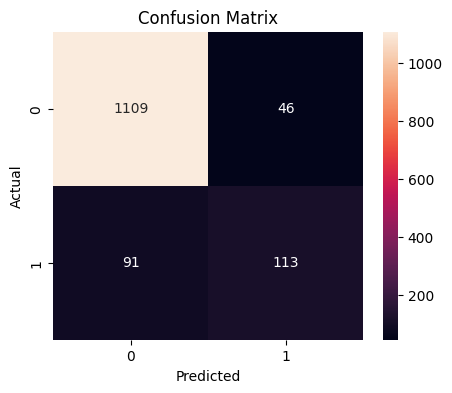

In [17]:
cm = confusion_matrix(Y_test, test_preds)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Look at the import

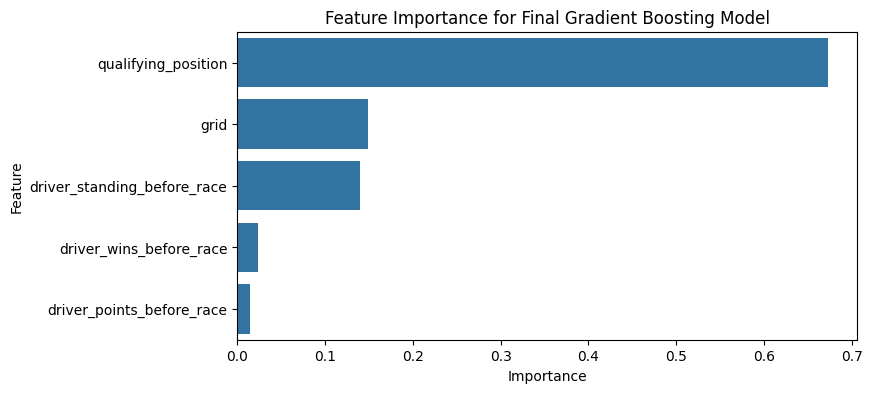

In [18]:
importance_df = pd.DataFrame({
    "feature": best_features,
    "importance": final_model.feature_importances_
})

importance_df = importance_df.sort_values("importance", ascending=False)

plt.figure(figsize=(8,4))

sns.barplot(
    data=importance_df,
    x="importance",
    y="feature"
)

plt.title("Feature Importance for Final Gradient Boosting Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Race-level podium prediction

In [19]:
test_with_preds = test.copy()

test_with_preds["podium_probability"] = test_probs
test_with_preds["predicted_podium"] = test_preds

In [20]:
predicted_top3 = (
    test_with_preds
    .sort_values(["raceId", "podium_probability"], ascending=[True, False])
    .groupby("raceId")
    .head(3)
)

predicted_top3.head()

,raceId,driverId,driver_name,constructorId,name_constructor,circuitId,year,round,grid,qualifying_position,driver_points_before_race,driver_standing_before_race,driver_wins_before_race,constructor_points_before_race,constructor_standing_before_race,constructor_wins_before_race,podium,positionOrder,podium_probability,predicted_podium
9631,1074,844,Charles Leclerc,6,Ferrari,3,2022,1,1,1.0,0.0,99.0,0.0,0.0,99.0,0.0,1,1,0.653862,1
8532,1074,830,Max Verstappen,9,Red Bull,3,2022,1,2,2.0,0.0,99.0,0.0,0.0,99.0,0.0,0,19,0.532347,1
8780,1074,832,Carlos Sainz,6,Ferrari,3,2022,1,3,3.0,0.0,99.0,0.0,0.0,99.0,0.0,1,2,0.446499,0
9632,1075,844,Charles Leclerc,6,Ferrari,77,2022,2,2,2.0,26.0,1.0,1.0,44.0,1.0,1.0,1,2,0.693897,1
8781,1075,832,Carlos Sainz,6,Ferrari,77,2022,2,3,3.0,18.0,2.0,0.0,44.0,1.0,1.0,1,3,0.630252,1


In [21]:
race_scores = (
    predicted_top3
    .groupby("raceId")["podium"]
    .sum()
    .reset_index()
)

race_scores = race_scores.rename(columns={"podium": "actual_podiums_found"})

race_scores.head()

,raceId,actual_podiums_found
0,1074,2
1,1075,2
2,1076,2
3,1077,2
4,1078,3


In [22]:
race_scores["actual_podiums_found"].mean()

np.float64(1.9264705882352942)

In [23]:
final_results = pd.DataFrame([{
    "model": "Tuned Gradient Boosting",
    "feature_set": "driver_history",
    "accuracy": test_accuracy,
    "precision": test_precision,
    "recall": test_recall,
    "f1": test_f1,
    "roc_auc": test_auc,
    "avg_actual_podiums_found_per_race": race_scores["actual_podiums_found"].mean()
}])

final_results

,model,feature_set,accuracy,precision,recall,f1,roc_auc,avg_actual_podiums_found_per_race
0,Tuned Gradient Boosting,driver_history,0.899191,0.710692,0.553922,0.62259,0.936417,1.926471


In [24]:
final_results.to_csv("../data/processed/final_model_test_results.csv", index=False)

## Predict for One race

In [25]:
race_id = 1075

specific_race = test_with_preds[test_with_preds["raceId"] == race_id].copy()

specific_race_predictions = specific_race.sort_values(
    "podium_probability",
    ascending=False
)

specific_race_predictions[[
    "raceId",
    "year",
    "round",
    "driver_name",
    "name_constructor",
    "grid",
    "qualifying_position",
    "podium_probability",
    "predicted_podium",
    "podium",
]].head(10)

,raceId,year,round,driver_name,name_constructor,grid,qualifying_position,podium_probability,predicted_podium,podium
9632,1075,2022,2,Charles Leclerc,Ferrari,2,2.0,0.693897,1,1
8781,1075,2022,2,Carlos Sainz,Ferrari,3,3.0,0.630252,1,1
7150,1075,2022,2,Sergio Pérez,Red Bull,1,1.0,0.522064,1,0
8533,1075,2022,2,Max Verstappen,Red Bull,4,4.0,0.206494,0,1
9909,1075,2022,2,George Russell,Mercedes,6,6.0,0.189518,0,0
9077,1075,2022,2,Esteban Ocon,Alpine F1 Team,5,5.0,0.138294,0,0
8104,1075,2022,2,Kevin Magnussen,Haas F1 Team,10,10.0,0.077488,0,0
7864,1075,2022,2,Valtteri Bottas,Alfa Romeo,8,8.0,0.057057,0,0
289,1075,2022,2,Lewis Hamilton,Mercedes,15,16.0,0.053064,0,0
1022,1075,2022,2,Fernando Alonso,Alpine F1 Team,7,7.0,0.050291,0,0


In [26]:
predicted_podium = specific_race_predictions.head(3)[[
    "driver_name",
    "name_constructor",
    "podium_probability",
    "positionOrder"
]]

actual_podium = specific_race_predictions[
    specific_race_predictions["podium"] == 1
][[
    "driver_name",
    "name_constructor",
    "podium_probability",
    "positionOrder"
]].sort_values("positionOrder")

print("Predicted Podium:")
display(predicted_podium)

print("Actual Podium:")
display(actual_podium)

Predicted Podium:


,driver_name,name_constructor,podium_probability,positionOrder
9632,Charles Leclerc,Ferrari,0.693897,2
8781,Carlos Sainz,Ferrari,0.630252,3
7150,Sergio Pérez,Red Bull,0.522064,4


Actual Podium:


,driver_name,name_constructor,podium_probability,positionOrder
8533,Max Verstappen,Red Bull,0.206494,1
9632,Charles Leclerc,Ferrari,0.693897,2
8781,Carlos Sainz,Ferrari,0.630252,3


## Row level podium accuracy

In [27]:
(test_with_preds["predicted_podium"] == test_with_preds["podium"]).mean()

np.float64(0.8991905813097866)

## Race level podium accuracy

In [28]:
predicted_top3 = (
    test_with_preds
    .sort_values(["raceId", "podium_probability"], ascending=[True, False])
    .groupby("raceId")
    .head(3)
)

In [29]:
race_scores = (
    predicted_top3
    .groupby("raceId")["podium"]
    .sum()
    .reset_index()
)

race_scores = race_scores.rename(columns={"podium": "actual_podiums_found"})

race_scores.head()

,raceId,actual_podiums_found
0,1074,2
1,1075,2
2,1076,2
3,1077,2
4,1078,3


In [30]:
race_scores["actual_podiums_found"].mean() / 3

np.float64(0.6421568627450981)

In [31]:
total_correct = race_scores["actual_podiums_found"].sum()
total_possible = len(race_scores) * 3

print("Total correct podium picks:", total_correct)
print("Total possible podium picks:", total_possible)
print("Percent correct:", total_correct / total_possible)

Total correct podium picks: 131
Total possible podium picks: 204
Percent correct: 0.6421568627450981


In [32]:
race_scores["actual_podiums_found"].value_counts().sort_index()

actual_podiums_found
1    17
2    39
3    12
Name: count, dtype: int64

64.2% of podium slots correctly identified

# Driver and Constructor History

In [33]:
best_features = [
    "grid",
    "qualifying_position",
    "driver_points_before_race",
    "driver_standing_before_race",
    "driver_wins_before_race",
    "constructor_points_before_race",
    "constructor_standing_before_race",
    "constructor_wins_before_race"
]



In [34]:
X_train = train[best_features]
Y_train = train["podium"]

X_val = val[best_features]
Y_val = val["podium"]

X_test = test[best_features]
Y_test = test["podium"]

## Tuning

In [35]:
results = []
n_estimators_list = [50, 100, 200]
learning_rate_list = [0.01, 0.05, 0.1]
max_depth_list = [1, 2, 3]

In [36]:
for n in n_estimators_list:
    
    for rate in learning_rate_list:
        
        for depth in max_depth_list:
            
            model = GradientBoostingClassifier(
                n_estimators=n,
                learning_rate=rate,
                max_depth=depth,
                random_state=42
            )
            
            model.fit(X_train, Y_train)
            
            val_preds = model.predict(X_val)
            val_probs = model.predict_proba(X_val)[:, 1]
            
            results.append({
                "n_estimators": n,
                "learning_rate": rate,
                "max_depth": depth,
                "accuracy": accuracy_score(Y_val, val_preds),
                "precision": precision_score(Y_val, val_preds, zero_division=0),
                "recall": recall_score(Y_val, val_preds, zero_division=0),
                "f1": f1_score(Y_val, val_preds, zero_division=0),
                "roc_auc": roc_auc_score(Y_val, val_probs)
            })

In [37]:
new_tuning_df = pd.DataFrame(results)

new_tuning_df.sort_values("roc_auc", ascending=False).head(10)

,n_estimators,learning_rate,max_depth,accuracy,precision,recall,f1,roc_auc
5,50,0.05,3,0.913952,0.754967,0.633333,0.688822,0.935191
22,200,0.05,2,0.914787,0.746835,0.655556,0.698225,0.934868
11,100,0.01,3,0.887218,0.835821,0.311111,0.453441,0.934598
20,200,0.01,3,0.911445,0.753425,0.611111,0.674847,0.934415
14,100,0.05,3,0.916458,0.753165,0.661111,0.704142,0.934186
15,100,0.10,1,0.914787,0.729412,0.688889,0.708571,0.934043
8,50,0.10,3,0.918964,0.764331,0.666667,0.712166,0.933885
16,100,0.10,2,0.918129,0.759494,0.666667,0.710059,0.933776
24,200,0.10,1,0.913952,0.722543,0.694444,0.708215,0.933762
21,200,0.05,1,0.916458,0.735294,0.694444,0.714286,0.933454


In [38]:
new_tuning_df.to_csv("../data/processed/driver_const_gradient_boosting_tuning_results.csv", index=False)

In [39]:
best_row = new_tuning_df.sort_values("roc_auc", ascending=False).iloc[0]

best_n_estimators = int(best_row["n_estimators"])
best_learning_rate = best_row["learning_rate"]
best_max_depth = int(best_row["max_depth"])

## Final Model

In [40]:
train_val = pd.concat([train, val])

X_train_val = train_val[best_features]
Y_train_val = train_val["podium"]

final_model = GradientBoostingClassifier(
    n_estimators=best_n_estimators,
    learning_rate=best_learning_rate,
    max_depth=best_max_depth,
    random_state=42
)

final_model.fit(X_train_val, Y_train_val)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",np.float64(0.05)
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",50
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N`

In [41]:
test_preds = final_model.predict(X_test)
test_probs = final_model.predict_proba(X_test)[:, 1]

In [42]:
test_accuracy = accuracy_score(Y_test, test_preds)
test_precision = precision_score(Y_test, test_preds, zero_division=0)
test_recall = recall_score(Y_test, test_preds, zero_division=0)
test_f1 = f1_score(Y_test, test_preds, zero_division=0)
test_auc = roc_auc_score(Y_test, test_probs)

print("Final Test Results")
print("Accuracy:", test_accuracy)
print("Precision:", test_precision)
print("Recall:", test_recall)
print("F1 Score:", test_f1)
print("ROC-AUC:", test_auc)

Final Test Results
Accuracy: 0.8977189109639441
Precision: 0.7096774193548387
Recall: 0.5392156862745098
F1 Score: 0.6128133704735376
ROC-AUC: 0.9332442067736186


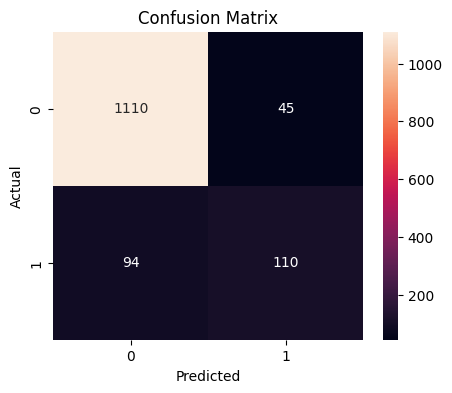

In [43]:
cm = confusion_matrix(Y_test, test_preds)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

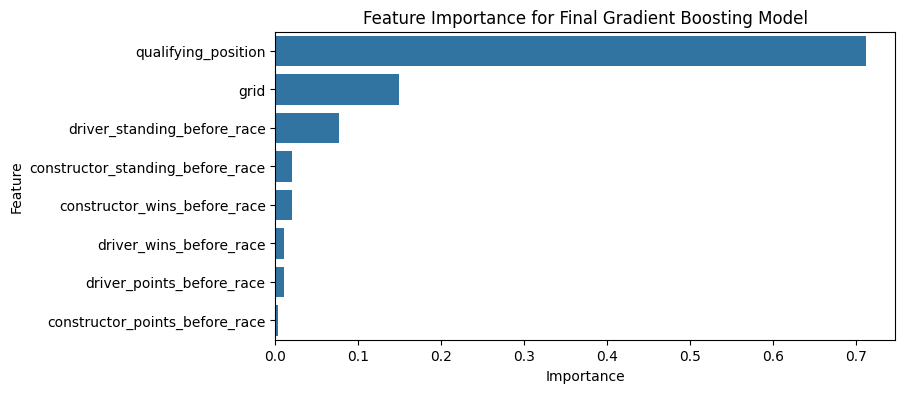

In [44]:
importance_df = pd.DataFrame({
    "feature": best_features,
    "importance": final_model.feature_importances_
})

importance_df = importance_df.sort_values("importance", ascending=False)

plt.figure(figsize=(8,4))

sns.barplot(
    data=importance_df,
    x="importance",
    y="feature"
)

plt.title("Feature Importance for Final Gradient Boosting Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Race-level podium prediction

In [45]:
test_with_preds = test.copy()

test_with_preds["podium_probability"] = test_probs
test_with_preds["predicted_podium"] = test_preds

In [46]:
predicted_top3 = (
    test_with_preds
    .sort_values(["raceId", "podium_probability"], ascending=[True, False])
    .groupby("raceId")
    .head(3)
)

predicted_top3.head()

,raceId,driverId,driver_name,constructorId,name_constructor,circuitId,year,round,grid,qualifying_position,driver_points_before_race,driver_standing_before_race,driver_wins_before_race,constructor_points_before_race,constructor_standing_before_race,constructor_wins_before_race,podium,positionOrder,podium_probability,predicted_podium
9631,1074,844,Charles Leclerc,6,Ferrari,3,2022,1,1,1.0,0.0,99.0,0.0,0.0,99.0,0.0,1,1,0.582847,1
8532,1074,830,Max Verstappen,9,Red Bull,3,2022,1,2,2.0,0.0,99.0,0.0,0.0,99.0,0.0,0,19,0.494278,0
8780,1074,832,Carlos Sainz,6,Ferrari,3,2022,1,3,3.0,0.0,99.0,0.0,0.0,99.0,0.0,1,2,0.411523,0
9632,1075,844,Charles Leclerc,6,Ferrari,77,2022,2,2,2.0,26.0,1.0,1.0,44.0,1.0,1.0,1,2,0.660849,1
8781,1075,832,Carlos Sainz,6,Ferrari,77,2022,2,3,3.0,18.0,2.0,0.0,44.0,1.0,1.0,1,3,0.577183,1


In [47]:
race_scores = (
    predicted_top3
    .groupby("raceId")["podium"]
    .sum()
    .reset_index()
)

race_scores = race_scores.rename(columns={"podium": "actual_podiums_found"})

race_scores.head()

,raceId,actual_podiums_found
0,1074,2
1,1075,2
2,1076,2
3,1077,2
4,1078,3


In [48]:
race_scores["actual_podiums_found"].mean()

np.float64(1.8970588235294117)

In [49]:
final_results = pd.DataFrame([{
    "model": "Tuned Gradient Boosting",
    "feature_set": "driver_constructor_history",
    "accuracy": test_accuracy,
    "precision": test_precision,
    "recall": test_recall,
    "f1": test_f1,
    "roc_auc": test_auc,
    "avg_actual_podiums_found_per_race": race_scores["actual_podiums_found"].mean()
}])

final_results

,model,feature_set,accuracy,precision,recall,f1,roc_auc,avg_actual_podiums_found_per_race
0,Tuned Gradient Boosting,driver_constructor_history,0.897719,0.709677,0.539216,0.612813,0.933244,1.897059


In [50]:
final_results.to_csv("../data/processed/driver_const_final_model_test_results.csv", index=False)

In [51]:
race_id = 1075

specific_race = test_with_preds[test_with_preds["raceId"] == race_id].copy()

specific_race_predictions = specific_race.sort_values(
    "podium_probability",
    ascending=False
)

specific_race_predictions[[
    "raceId",
    "year",
    "round",
    "driver_name",
    "name_constructor",
    "grid",
    "qualifying_position",
    "podium_probability",
    "predicted_podium",
    "podium",
]].head(10)

,raceId,year,round,driver_name,name_constructor,grid,qualifying_position,podium_probability,predicted_podium,podium
9632,1075,2022,2,Charles Leclerc,Ferrari,2,2.0,0.660849,1,1
8781,1075,2022,2,Carlos Sainz,Ferrari,3,3.0,0.577183,1,1
7150,1075,2022,2,Sergio Pérez,Red Bull,1,1.0,0.463069,0,0
8533,1075,2022,2,Max Verstappen,Red Bull,4,4.0,0.190735,0,1
9909,1075,2022,2,George Russell,Mercedes,6,6.0,0.175195,0,0
9077,1075,2022,2,Esteban Ocon,Alpine F1 Team,5,5.0,0.104068,0,0
8104,1075,2022,2,Kevin Magnussen,Haas F1 Team,10,10.0,0.079347,0,0
10278,1075,2022,2,Mick Schumacher,Haas F1 Team,0,14.0,0.059048,0,0
289,1075,2022,2,Lewis Hamilton,Mercedes,15,16.0,0.058223,0,0
7864,1075,2022,2,Valtteri Bottas,Alfa Romeo,8,8.0,0.055544,0,0


In [52]:
predicted_podium = specific_race_predictions.head(3)[[
    "driver_name",
    "name_constructor",
    "podium_probability",
    "positionOrder"
]]

actual_podium = specific_race_predictions[
    specific_race_predictions["podium"] == 1
][[
    "driver_name",
    "name_constructor",
    "podium_probability",
    "positionOrder"
]].sort_values("positionOrder")

print("Predicted Podium:")
display(predicted_podium)

print("Actual Podium:")
display(actual_podium)

Predicted Podium:


,driver_name,name_constructor,podium_probability,positionOrder
9632,Charles Leclerc,Ferrari,0.660849,2
8781,Carlos Sainz,Ferrari,0.577183,3
7150,Sergio Pérez,Red Bull,0.463069,4


Actual Podium:


,driver_name,name_constructor,podium_probability,positionOrder
8533,Max Verstappen,Red Bull,0.190735,1
9632,Charles Leclerc,Ferrari,0.660849,2
8781,Carlos Sainz,Ferrari,0.577183,3


## Row level podium accuracy

In [53]:
(test_with_preds["predicted_podium"] == test_with_preds["podium"]).mean()

np.float64(0.8977189109639441)

## Row level podium accuracy

In [54]:
predicted_top3 = (
    test_with_preds
    .sort_values(["raceId", "podium_probability"], ascending=[True, False])
    .groupby("raceId")
    .head(3)
)

In [55]:
race_scores = (
    predicted_top3
    .groupby("raceId")["podium"]
    .sum()
    .reset_index()
)

race_scores = race_scores.rename(columns={"podium": "actual_podiums_found"})

race_scores.head()

,raceId,actual_podiums_found
0,1074,2
1,1075,2
2,1076,2
3,1077,2
4,1078,3


In [56]:
race_scores["actual_podiums_found"].mean() / 3

np.float64(0.6323529411764706)

In [57]:
total_correct = race_scores["actual_podiums_found"].sum()
total_possible = len(race_scores) * 3

print("Total correct podium picks:", total_correct)
print("Total possible podium picks:", total_possible)
print("Percent correct:", total_correct / total_possible)

Total correct podium picks: 129
Total possible podium picks: 204
Percent correct: 0.6323529411764706


In [58]:
race_scores["actual_podiums_found"].value_counts().sort_index()

actual_podiums_found
0     1
1    17
2    38
3    12
Name: count, dtype: int64

 ### Adding constructor history features did not improve the final model. The driver-history model had better ROC-AUC, F1 score, and race-level podium accuracy.